# <a id='toc1_'></a>[Web Scraping for NVIDIA and Intel](#toc0_)
*Alexander Thompson, B.S.c*

**Table of contents**<a id='toc0_'></a>    
- [Web Scraping for NVIDIA and Intel](#toc1_)    
  - [NVIDIA](#toc1_1_)    
    - [NVIDIA Revenue](#toc1_1_1_)    
    - [NVIDIA Share Price](#toc1_1_2_)    
  - [Intel](#toc1_2_)    
    - [Intel Share Price](#toc1_2_1_)    
    - [Intel's Revenue](#toc1_2_2_)    
  - [Intel and NVIDIA Revenue](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

This is the data collection for the NVIDIA data for my case study as part of my presentation to Grayce.

## <a id='toc1_1_'></a>[NVIDIA](#toc0_)

### <a id='toc1_1_1_'></a>[NVIDIA Revenue](#toc0_)

The first thing to do is to collect the Revenue data for NVIDIA to display the effects of the AI Boom.

For this, we will use the Macrotrends website, and have a look at thier rules to webscraping.

This can be found in their `/robots.txt` endpoint.

![Robots.txt](Robots.png)

Here we can see what URL paths are not allowed for web scraping.

We are okay as URL begins with `stocks/charts/` and so we can proceed

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import datetime

Lets send a GET request to the website.

In [3]:
url = 'https://www.macrotrends.net/stocks/charts/NVDA/nvidia/revenue'
headers = {"User-Agent": "Mozilla/5.0"}
r = requests.get(url, headers=headers)

Let's check to see if the request was successful

In [4]:
r.status_code

200

It was and we can no proceed to parse the HTML Data using BeautifulSoup

In [5]:
data = r.text
nvidia_rev = BeautifulSoup(data, 'html5lib')

Now lets locate where our Revenue data is on the webpage, we will go on the webpage and using inspect element, find the appropriate table.

Here we use ctrl+f to search for the word table, we find that the quarterly revenue table for NVIDIA is the 2nd table out of 36 in the search list. Python has 0 based indexing and so this will be at index 1 in the `nvidia_rev` Soup Object.

![NVIDIA](NVIDIA_Inspect_Element.png)

In [6]:
table = nvidia_rev.find_all('tbody')[1]

In [7]:
nvidia_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

In [8]:
for row in table.find_all('tr'):
    col = row.find_all('td')
    date = col[0].text
    revenue = col[1].text
    nvidia_revenue = pd.concat([nvidia_revenue, pd.DataFrame({'Date': [date],
                                                              'Revenue': [revenue]}
                                                              )], ignore_index=True)

In [9]:
nvidia_revenue.head(5)

,Date,Revenue
0,2026-04-30,"$81,615"
1,2026-01-31,"$68,127"
2,2025-10-31,"$57,006"
3,2025-07-31,"$46,743"
4,2025-04-30,"$44,062"


Lets clean the data so it is ready for analysis

In [10]:
nvidia_revenue['Revenue'] = nvidia_revenue['Revenue'].str.replace(',|\$', "", regex=True)

In [11]:
nvidia_revenue.dropna(inplace=True)
nvidia_revenue = nvidia_revenue[nvidia_revenue['Revenue'] != ""]

In [12]:
nvidia_revenue.head()

,Date,Revenue
0,2026-04-30,81615
1,2026-01-31,68127
2,2025-10-31,57006
3,2025-07-31,46743
4,2025-04-30,44062


In [13]:
nvidia_revenue['Date'] = pd.to_datetime(nvidia_revenue['Date'])

In [14]:
nvidia_revenue['Date_Q'] = nvidia_revenue['Date'].dt.to_period('Q').dt.strftime('%Y-Q%q')

In [16]:
nvidia_revenue['Revenue'] = nvidia_revenue['Revenue'].astype(float)

In [15]:
nvidia_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     60 non-null     datetime64[ns]
 1   Revenue  60 non-null     object        
 2   Date_Q   60 non-null     object        
dtypes: datetime64[ns](1), object(2)
memory usage: 1.5+ KB


In [17]:
nvidia_revenue = nvidia_revenue.sort_values(by=['Date'], ascending=True)
nvidia_revenue.head()

,Date,Revenue,Date_Q
59,2011-07-31,1017.0,2011-Q3
58,2011-10-31,1066.0,2011-Q4
57,2012-01-31,953.0,2012-Q1
56,2012-04-30,925.0,2012-Q2
55,2012-07-31,1044.0,2012-Q3


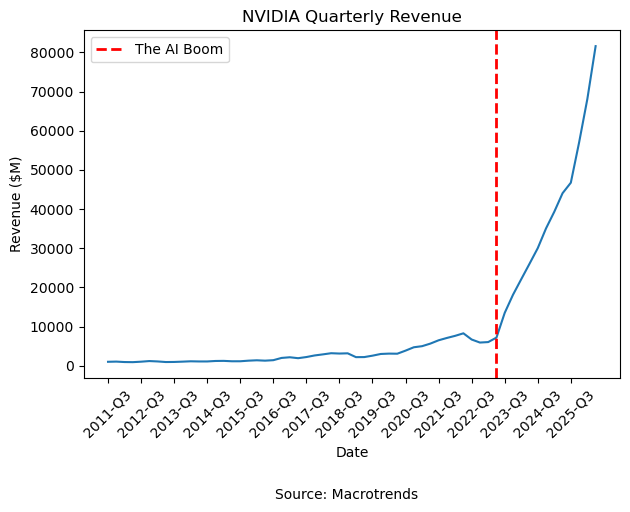

In [83]:
plt.plot(nvidia_revenue['Date_Q'], nvidia_revenue['Revenue'])
plt.axvline(x='2023-Q2', color='red', linestyle="--", linewidth=2, label="The AI Boom")
plt.title("NVIDIA Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($M)")
plt.xticks(ticks=nvidia_revenue['Date_Q'][::4], labels=nvidia_revenue['Date_Q'][::4], rotation=45)
plt.figtext(0.55, -0.05, "Source: Macrotrends", ha="center", fontsize=10)
plt.tight_layout()
plt.legend()
plt.show()

In [20]:
nvidia_revenue.to_csv("NVIDIA Revenue.csv", index=False)

### <a id='toc1_1_2_'></a>[NVIDIA Share Price](#toc0_)

Here we will use the yfinance api to get the share price for NVIDIA.

In [21]:
nvidia = yf.Ticker("NVDA")

We can see the highest share price of NVIDIA today.

In [22]:
nvidia.info['dayHigh']

232.28

We can also see NVIDIA's 5 Trillion Dollar Valuation

In [23]:
nvidia.info['marketCap']

5396923154432

We will use the `.history()` method to extract the stock price data for NVIDIA.

In [24]:
nvidia_price = nvidia.history(period='3mo')

In [ ]:
nvidia_price.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-03 00:00:00-05:00,178.480340,180.890198,176.910417,180.040253,178099400,0.0,0.0
2026-03-04 00:00:00-05:00,180.430240,184.690004,180.050256,183.030090,177731200,0.0,0.0
2026-03-05 00:00:00-05:00,181.160197,184.050040,177.870382,183.330078,198779700,0.0,0.0
2026-03-06 00:00:00-05:00,179.830259,182.750099,176.810433,177.810379,189021900,0.0,0.0
2026-03-09 00:00:00-04:00,176.820429,182.900102,175.550494,182.640106,177213600,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,214.119995,214.149994,208.779999,212.600006,167601200,0.0,0.0
2026-05-28 00:00:00-04:00,211.279999,215.520004,211.220001,214.250000,143996000,0.0,0.0
2026-05-29 00:00:00-04:00,214.580002,217.860001,211.130005,211.139999,289410600,0.0,0.0


We will filter the dataset to go up to the 1st of June 2026.

This is due to the announcement made at the NVIDIA GTC in Taipei, where NVIDIA showcased the RTX Spark.

In [26]:
nvidia_price = nvidia_price[nvidia_price.index <= '2026-06-01']
nvidia_price.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-26 00:00:00-04:00,216.539993,218.179993,212.000000,214.860001,187202600,0.0,0.0
2026-05-27 00:00:00-04:00,214.119995,214.149994,208.779999,212.600006,167601200,0.0,0.0
2026-05-28 00:00:00-04:00,211.279999,215.520004,211.220001,214.250000,143996000,0.0,0.0
2026-05-29 00:00:00-04:00,214.580002,217.860001,211.130005,211.139999,289410600,0.0,0.0
2026-06-01 00:00:00-04:00,215.729996,224.869995,215.699997,224.360001,212850700,0.0,0.0


Now lets visualise this.

We will use plotly to make candlestick charts of the share price for NVIDIA.

In [28]:
fig = go.Figure(data=[go.Candlestick(x=nvidia_price.index,
                                     open=nvidia_price['Open'],
                                     close=nvidia_price['Close'],
                                     high=nvidia_price['High'],
                                     low=nvidia_price['Low'])
                                     ])
fig.update_layout(title="NVIDIA Stock Price",
                  xaxis_title="Date",
                  yaxis_title="Price ($)",
                  xaxis_rangeslider_visible=False)
fig.show()

In [32]:
latest_date = nvidia_price.index[-1]
latest_close = nvidia_price['Close'].iloc[-1]
previous_close = nvidia_price['Close'].iloc[-2]
price_change = latest_close - previous_close
percent_change = (price_change/previous_close)*100

fig = go.Figure(data=[go.Candlestick(x=nvidia_price.index,
                                     open=nvidia_price['Open'],
                                     close=nvidia_price['Close'],
                                     high=nvidia_price['High'],
                                     low=nvidia_price['Low'],
                                     name="NVDA")
                                     ])
# Adding the Horizontal Line at the latest closing price
fig.add_hline(y=latest_close,
              line_dash="dash",
              line_color="red",
              annotation_text=f"Latest Close: ${latest_close:.2f}",
              annotation_position="top")
# Adding the Arrow Annotation
fig.add_annotation(x=latest_date,
                   y=latest_close,
                   text=f"${latest_close:.2f}<br>{percent_change:+.2f}%",
                   showarrow=True,
                   arrowhead=2,
                   ax=-60,
                   ay=-40,
                   bgcolor="black",
                   bordercolor="red",
                   borderwidth=1,
                   font=dict(size=12))
# Adding the caption
fig.add_annotation(text="Source: Yahoo Finance via the yfinance API. NVIDIA share price shown over a 3-month period using daily OHLC data.",
                   xref="paper",
                   yref="paper",
                   x=0,
                   y=-0.28,
                   showarrow=False,
                   font=dict(size=11),
                   align="left")

# Hide weekends with range breaks
fig.update_xaxes(rangebreaks=[dict(bounds=['sat', 'mon'])])

fig.update_layout(title="NVIDIA Share Price",
                  xaxis_title="Date",
                  yaxis_title="Price ($)",
                  xaxis_rangeslider_visible=False,
                  template="plotly_dark")
fig.show()

In [33]:
nvidia_price.to_csv("NVIDIA Share Price 3 Months.csv", index=False)

## <a id='toc1_2_'></a>[Intel](#toc0_)

### <a id='toc1_2_1_'></a>[Intel Share Price](#toc0_)

We will now get the share price for Intel, to display the effects of the NVIDIA GTC announcement of the RGX Spark chip.

In [34]:
intel = yf.Ticker("INTC")

Let's see Intel's Market valuation.

In [35]:
intel.info['marketCap']

542456152064

Lets get the share price over the past 3 months

In [36]:
intel_price = intel.history(period="3mo")

In [37]:
intel_price.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-27 00:00:00-04:00,124.389999,125.269997,117.000000,121.769997,93323300,0.0,0.0
2026-05-28 00:00:00-04:00,121.449997,123.080002,116.309998,120.889999,97321000,0.0,0.0
2026-05-29 00:00:00-04:00,123.849998,126.639999,113.540001,114.680000,191676100,0.0,0.0
2026-06-01 00:00:00-04:00,109.430000,113.300003,106.330002,109.330002,134900400,0.0,0.0
2026-06-02 00:00:00-04:00,107.425003,109.000000,104.169998,107.930000,104474192,0.0,0.0


When visualising the share price, we want to visualise the percentage change for the 1st June 2026, and so we will eliminate 2nd June 2026 from our data.

In [38]:
intel_price.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [39]:
intel_price = intel_price[intel_price.index <= '2026-06-01']
intel_price.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-26 00:00:00-04:00,122.099998,125.620003,117.349998,123.519997,108167300,0.0,0.0
2026-05-27 00:00:00-04:00,124.389999,125.269997,117.000000,121.769997,93323300,0.0,0.0
2026-05-28 00:00:00-04:00,121.449997,123.080002,116.309998,120.889999,97321000,0.0,0.0
2026-05-29 00:00:00-04:00,123.849998,126.639999,113.540001,114.680000,191676100,0.0,0.0
2026-06-01 00:00:00-04:00,109.430000,113.300003,106.330002,109.330002,134900400,0.0,0.0


In [40]:
intel_price.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-03 00:00:00-05:00,43.439999,43.689999,42.139999,43.099998,83971000,0.0,0.0
2026-03-04 00:00:00-05:00,44.070000,46.130001,43.270000,45.580002,96628100,0.0,0.0
2026-03-05 00:00:00-05:00,44.869999,46.480000,44.700001,45.950001,78229400,0.0,0.0
2026-03-06 00:00:00-05:00,44.669998,45.180000,43.279999,43.419998,74698300,0.0,0.0
2026-03-09 00:00:00-04:00,42.740002,45.759998,41.639999,45.580002,82937400,0.0,0.0


Lets visualise this as a candlestick chart.

In [42]:
latest_date = intel_price.index[-1]
latest_close = intel_price['Close'].iloc[-1]
previous_close = intel_price['Close'].iloc[-2]
price_change = latest_close - previous_close
percent_change = (price_change/previous_close)*100

In [43]:
fig = go.Figure(data=[go.Candlestick(x=intel_price.index,
                                     open=intel_price['Open'],
                                     close=intel_price['Close'],
                                     high=intel_price['High'],
                                     low=intel_price['Low'],
                                     name='INTC')
                                     ])

# Horizontal Line
fig.add_hline(y=latest_close,
              line_dash="dash",
              line_color="red",
              annotation_text=f"Latest Close: ${latest_close:.2f}",
              annotation_position="top")

# Arrow Annotation
fig.add_annotation(x=latest_date,
                   y=latest_close,
                   text=f"${latest_close:.2f}<br>{percent_change:+.1f}%",
                   showarrow=True,
                   arrowhead=2,
                   ax=-60,
                   ay=40,
                   bgcolor="black",
                   bordercolor="red",
                   borderwidth=1,
                   font=dict(size=12))

# Caption
fig.add_annotation(text="Source: Yahoo Finance via the yfinance API. Intel share price shown over a 3-month period using daily OHLC data.",
                   xref="paper",
                   yref="paper",
                   x=0,
                   y=-0.28,
                   showarrow=False,
                   font=dict(size=11),
                   align="left")

# Hiding the weekends
fig.update_xaxes(rangebreaks=[dict(bounds=['sat', 'mon'])])

# Layout
fig.update_layout(title="Intel Share Price",
                  xaxis_title="Date",
                  yaxis_title="Price ($)",
                  xaxis_rangeslider_visible=False,
                  template="plotly_dark")

fig.show()

In [ ]:
intel_price.to_csv("Intel Share Price 3 Months.csv", index=False)

### <a id='toc1_2_2_'></a>[Intel's Revenue](#toc0_)

We will now use web scraping to obtain Intel's quarterly revenue.

Because we will be using Macrotrends again, we already know the permisions needed for their web scraping `robots.txt`

In [44]:
url = 'https://www.macrotrends.net/stocks/charts/INTC/intel/revenue'
header = {"User-Agent":"Mozilla/5.0"}
r = requests.get(url, headers=header)

In [45]:
r.status_code

200

In [46]:
response = r.text

In [47]:
intel_rev = BeautifulSoup(response, 'html5lib')

When looking on the Intel Revenue Macrotrends website, using ctrl+f and searching for table we can see that our quarterly revenue table is 2nd out of 16 in the list.

![intel](../Grayce/Intel%20Inspect%20Element.png)

Now lets parse the data into a dataframe

In [48]:
table = intel_rev.find_all('tbody')[1]

In [49]:
intel_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

In [50]:
for row in table.find_all('tr'):
    col = row.find_all('td')
    date = col[0].text
    revenue = col[1].text
    intel_revenue = pd.concat([intel_revenue, pd.DataFrame({'Date': [date],
                                                            'Revenue': [revenue]}
                                                            )], ignore_index=True)

In [51]:
intel_revenue.head()

,Date,Revenue
0,2026-03-31,"$13,577"
1,2025-12-31,"$13,674"
2,2025-09-30,"$13,653"
3,2025-06-30,"$12,859"
4,2025-03-31,"$12,667"


Lets clean and prepare the data for analysis.

In [52]:
intel_revenue['Revenue'] = intel_revenue['Revenue'].str.replace(',|\$', "", regex=True)

In [53]:
intel_revenue.isna().sum()

Date       0
Revenue    0
dtype: int64

In [54]:
intel_revenue = intel_revenue[intel_revenue['Revenue'] != ""]

In [56]:
intel_revenue['Date'] = pd.to_datetime(intel_revenue['Date'])

In [57]:
intel_revenue['Date_Q'] = intel_revenue['Date'].dt.to_period('Q').dt.strftime('%Y-Q%q')

In [55]:
intel_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     60 non-null     object
 1   Revenue  60 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


Let's convert the `Date` column into datetime

In [58]:
intel_revenue.head()

,Date,Revenue,Date_Q
0,2026-03-31,13577,2026-Q1
1,2025-12-31,13674,2025-Q4
2,2025-09-30,13653,2025-Q3
3,2025-06-30,12859,2025-Q2
4,2025-03-31,12667,2025-Q1


In [59]:
intel_revenue['Revenue'] = intel_revenue['Revenue'].astype(float)
intel_revenue = intel_revenue.sort_values(by=['Date'], ascending=True)
intel_revenue = intel_revenue.reset_index(drop=True)
intel_revenue.head()

,Date,Revenue,Date_Q
0,2011-06-30,13032.0,2011-Q2
1,2011-09-30,14233.0,2011-Q3
2,2011-12-31,13887.0,2011-Q4
3,2012-03-31,12906.0,2012-Q1
4,2012-06-30,13501.0,2012-Q2


Now let's visualise it

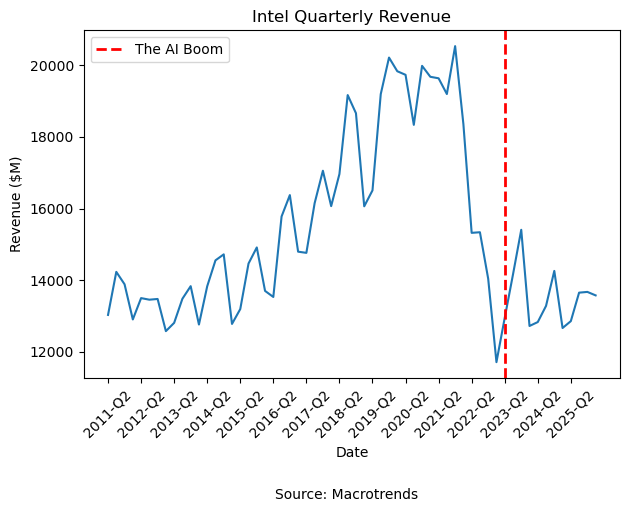

In [81]:
plt.plot(intel_revenue['Date_Q'], intel_revenue['Revenue'])
plt.title("Intel Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($M)")
plt.axvline(x='2023-Q2', color='red', linestyle="--", linewidth=2, label="The AI Boom")
plt.xticks(ticks=intel_revenue['Date_Q'][::4],
           labels=intel_revenue['Date_Q'][::4],
           rotation=45)
plt.figtext(0.55, -0.05, "Source: Macrotrends", ha="center", fontsize=10)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
intel_revenue.to_csv("Intel Revenue.csv", index=False)

## <a id='toc1_3_'></a>[Intel and NVIDIA Revenue](#toc0_)

Here, we will visualise the quarterly revenue of both NVIDIA and Intel to show how NVIDIA adapted their technology to the market and innovated compared to Intel who failed to adapt and invest in AI acceleration.

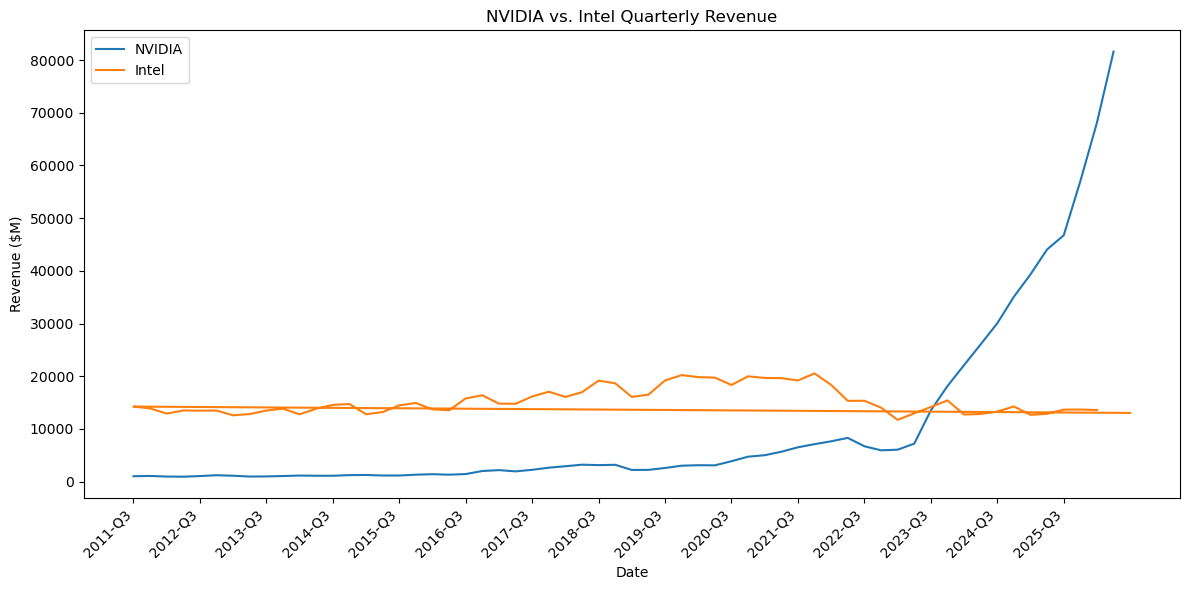

In [63]:
plt.figure(figsize=(12,6))

# NVIDIA
plt.plot(nvidia_revenue['Date_Q'], nvidia_revenue['Revenue'], label="NVIDIA")

# Intel
plt.plot(intel_revenue['Date_Q'], intel_revenue['Revenue'], label="Intel")

plt.title("NVIDIA vs. Intel Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($M)")
plt.xticks(ticks=nvidia_revenue['Date_Q'][::4],
           labels=nvidia_revenue['Date_Q'][::4],
           rotation=45,
           ha="right")
plt.legend()
plt.tight_layout()
plt.show()

This didn't turn out as planned as Intel's revenue is skewed here. Therefore, we will try using Seaborn instead of Matplotlib.

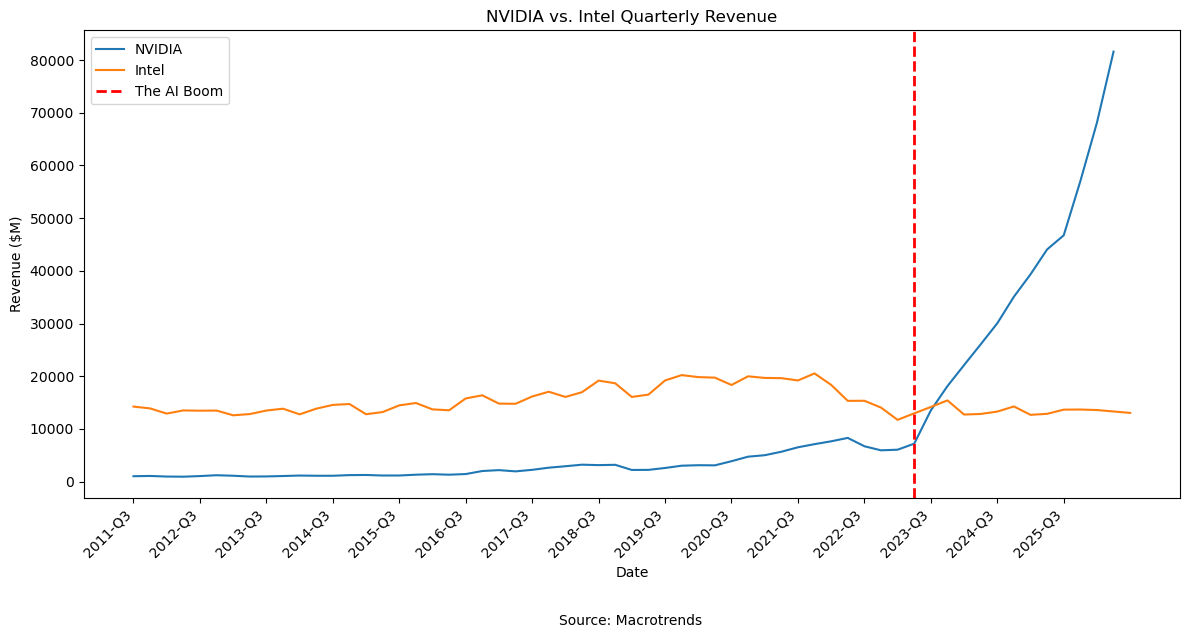

In [74]:
plt.figure(figsize=(12,6))
sns.lineplot(data=nvidia_revenue, x='Date_Q', y='Revenue', label='NVIDIA')
sns.lineplot(data=intel_revenue, x='Date_Q', y='Revenue', label='Intel')
plt.title("NVIDIA vs. Intel Quarterly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue ($M)")
plt.xticks(ticks=range(0, len(nvidia_revenue['Date_Q']), 4),
           labels=nvidia_revenue['Date_Q'][::4],
           rotation=45,
           ha='right')
plt.axvline(x='2023-Q2', color='red', linestyle="--", linewidth=2, label="The AI Boom")
plt.figtext(0.53, -0.05, "Source: Macrotrends", ha="center", fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Here we can see the significant difference between NVIDIA and Intel's quarterly revenue, with the AI Boom's effect on both companies.

NVIDIA's revenue accelerated sharply after the AI Boom, driven by early investment in GPUs, AI infrastructure and data centre computing.

Intel's revenue however remained comparatively flat and stagnant, thereby highlighting the impact of slower adaption and innovation to AI, GPUs and Accelerated Computing.

This therefore showcases the effects of adaptation to market behaviour and emerging technologies even for companies who have traditionally dominated the market.